# Insurance Customer Analytics using MongoDB & Machine Learning

## Project Overview

Insurance companies maintain customer information across multiple systems. Unlike traditional relational databases, MongoDB stores customer information as flexible document-based records, making it ideal for handling semi-structured data.

In this project, we will:

- Load customer insurance data
- Store the data inside MongoDB
- Learn MongoDB CRUD operations
- Perform Aggregation Pipeline analysis
- Build Machine Learning models
- Create a Streamlit application
- Deploy the project

## Technologies Used

- MongoDB
- PyMongo
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Scikit-Learn
- XGBoost
- Joblib

## Resources

In [12]:
# Uncomment if running for the first time
!pip install pymongo
!pip install dnspython
!pip install plotly
!pip install xgboost

## Imports

In [13]:
import warnings
warnings.filterwarnings("ignore")

import random
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pymongo import MongoClient

from pprint import pprint

from datetime import datetime, timedelta
import joblib

## Artifacts

In [14]:
import os

artifact_dirs = [
    "artifacts",
    "artifacts/raw_data",
    "artifacts/processed_data",
    "artifacts/plots",
    "artifacts/plots/matplotlib",
    "artifacts/models",
    "artifacts/encoders",
    "artifacts/scalers",
    "artifacts/metrics"
]

for directory in artifact_dirs:
    os.makedirs(directory, exist_ok=True)

print("✅ All necessary artifact directories created successfully.")

✅ All necessary artifact directories created successfully.


## Data Loading

In [15]:
df = pd.read_csv("artifacts/raw_data/train.csv")

df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## Exploratory Data Analysis (EDA)

In [16]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 381,109
Columns : 12


### Dataset Info

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


### Descriptive Statistics

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,381109.0,190555.000000,110016.836208,1.0,95278.0,190555.0,285832.0,381109.0
Age,381109.0,38.822584,15.511611,20.0,25.0,36.0,49.0,85.0
Driving_License,381109.0,0.997869,0.046110,0.0,1.0,1.0,1.0,1.0
Region_Code,381109.0,26.388807,13.229888,0.0,15.0,28.0,35.0,52.0
Previously_Insured,381109.0,0.458210,0.498251,0.0,0.0,0.0,1.0,1.0
Annual_Premium,381109.0,30564.389581,17213.155057,2630.0,24405.0,31669.0,39400.0,540165.0
Policy_Sales_Channel,381109.0,112.034295,54.203995,1.0,29.0,133.0,152.0,163.0
Vintage,381109.0,154.347397,83.671304,10.0,82.0,154.0,227.0,299.0
Response,381109.0,0.122563,0.327936,0.0,0.0,0.0,0.0,1.0


### Missing Values and Duplicates

In [19]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
Driving_License,0
Region_Code,0
Previously_Insured,0
Vehicle_Age,0
Vehicle_Damage,0
Annual_Premium,0
Policy_Sales_Channel,0


### Check for Duplicates

In [20]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


### Unique Values

In [21]:
df.nunique().sort_values()

,0
Gender,2
Driving_License,2
Vehicle_Damage,2
Previously_Insured,2
Response,2
Vehicle_Age,3
Region_Code,53
Age,66
Policy_Sales_Channel,155
Vintage,290


### Column Names

In [22]:
df.columns.tolist()

['id',
 'Gender',
 'Age',
 'Driving_License',
 'Region_Code',
 'Previously_Insured',
 'Vehicle_Age',
 'Vehicle_Damage',
 'Annual_Premium',
 'Policy_Sales_Channel',
 'Vintage',
 'Response']

### Sample Data

In [23]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


#### Last Rows

In [24]:
df.tail()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0
381108,381109,Male,46,1,29.0,0,1-2 Year,No,41777.0,26.0,237,0


#### Random Sample

In [25]:
df.sample(5, random_state=42)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
200222,200223,Female,21,1,3.0,1,< 1 Year,No,20408.0,160.0,72,0
49766,49767,Male,55,1,15.0,0,1-2 Year,Yes,37498.0,26.0,102,0
172201,172202,Female,41,1,3.0,0,1-2 Year,Yes,2630.0,26.0,90,0
160713,160714,Female,26,1,11.0,0,< 1 Year,No,2630.0,151.0,268,0
53272,53273,Male,51,1,40.0,0,1-2 Year,Yes,34006.0,124.0,265,0


# MongoDB Fundamentals

MongoDB is a NoSQL document-oriented database that stores data in BSON (Binary JSON) format instead of tables.

Unlike relational databases where data is stored in rows and columns, MongoDB stores information as flexible JSON-like documents.

Advantages:

- Flexible Schema
- Nested Documents
- Arrays
- Horizontal Scaling
- High Performance
- Suitable for Big Data Applications

In this project, we will transform traditional tabular insurance data into nested MongoDB documents to better represent real-world customer information.

### MongoDB Setup

In [26]:
# Install MongoDB Mock Library

!pip -q install mongomock pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.8 MB/s eta 0:00:00


#### Import MongoDB Libraries

In [27]:
import mongomock
from pprint import pprint

#### Connect to MongoDB (Mock)

In [28]:
client = mongomock.MongoClient()

db = client["insurance_customer_analytics"]

customers = db["customers"]

print("✅ MongoMock Connected Successfully")

✅ MongoMock Connected Successfully


#### MongoDB Basic Operations

In [29]:
client.list_database_names()

[]

##### Insert Data

In [30]:
customers.insert_one({"name": "Gourav"})

InsertOneResult(ObjectId('6a66141c30c462c901a89e17'), acknowledged=True)

##### Database Names

In [31]:
client.list_database_names()

['insurance_customer_analytics']

##### Collections Names

In [32]:
db.list_collection_names()

['customers']

###### Find One Document

In [33]:
customers.find_one()

{'name': 'Gourav', '_id': ObjectId('6a66141c30c462c901a89e17')}

###### Count Documents

In [34]:
customers.count_documents({})

1

##### Delete Data

In [35]:
customers.delete_many({})

DeleteResult({'connectionId': 0, 'n': 1, 'ok': 1.0, 'err': None}, acknowledged=True)

###### Confirm Deletion

In [36]:
customers.count_documents({})

0

##### Prepare Data for Insertion

In [37]:
documents = []

for _, row in df.iterrows():

    document = {

        "customer_id": int(row["id"]),

        "personal_info": {
            "gender": row["Gender"],
            "age": int(row["Age"])
        },

        "insurance": {
            "driving_license": bool(row["Driving_License"]),
            "previously_insured": bool(row["Previously_Insured"]),
            "annual_premium": float(row["Annual_Premium"])
        },

        "vehicle": {
            "vehicle_age": row["Vehicle_Age"],
            "vehicle_damage": row["Vehicle_Damage"]
        },

        "sales": {
            "region_code": int(row["Region_Code"]),
            "policy_channel": int(row["Policy_Sales_Channel"]),
            "vintage": int(row["Vintage"])
        },

        "response": int(row["Response"])
    }

    documents.append(document)

print(f"✅ {len(documents):,} documents prepared.")

✅ 381,109 documents prepared.


##### Example Document Structure

In [38]:
from pprint import pprint

pprint(documents[0])

{'customer_id': 1,
 'insurance': {'annual_premium': 40454.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 44, 'gender': 'Male'},
 'response': 1,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 217},
 'vehicle': {'vehicle_age': '> 2 Years', 'vehicle_damage': 'Yes'}}


##### Insert Documents

In [39]:
result = customers.insert_many(documents)

print("✅ Documents inserted successfully.")

✅ Documents inserted successfully.


##### Verify Insertion

In [40]:
customers.count_documents({})

381109

###### Find One Document

In [41]:
pprint(customers.find_one())

{'_id': ObjectId('6a66143030c462c901a89e18'),
 'customer_id': 1,
 'insurance': {'annual_premium': 40454.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 44, 'gender': 'Male'},
 'response': 1,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 217},
 'vehicle': {'vehicle_age': '> 2 Years', 'vehicle_damage': 'Yes'}}


###### Count Documents

In [42]:
customers.count_documents({})

381109

###### Find One Document

In [43]:
pprint(customers.find_one())

{'_id': ObjectId('6a66143030c462c901a89e18'),
 'customer_id': 1,
 'insurance': {'annual_premium': 40454.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 44, 'gender': 'Male'},
 'response': 1,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 217},
 'vehicle': {'vehicle_age': '> 2 Years', 'vehicle_damage': 'Yes'}}


###### Find Documents With Limit

In [44]:
for doc in customers.find().limit(5):
    pprint(doc)

{'_id': ObjectId('6a66143030c462c901a89e18'),
 'customer_id': 1,
 'insurance': {'annual_premium': 40454.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 44, 'gender': 'Male'},
 'response': 1,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 217},
 'vehicle': {'vehicle_age': '> 2 Years', 'vehicle_damage': 'Yes'}}
{'_id': ObjectId('6a66143030c462c901a89e19'),
 'customer_id': 2,
 'insurance': {'annual_premium': 33536.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 76, 'gender': 'Male'},
 'response': 0,
 'sales': {'policy_channel': 26, 'region_code': 3, 'vintage': 183},
 'vehicle': {'vehicle_age': '1-2 Year', 'vehicle_damage': 'No'}}
{'_id': ObjectId('6a66143030c462c901a89e1a'),
 'customer_id': 3,
 'insurance': {'annual_premium': 38294.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age':

###### Find Documents by Gender

In [45]:
male_customers = customers.find({
    "personal_info.gender": "Male"
})

for doc in male_customers.limit(5):
    pprint(doc)

{'_id': ObjectId('6a66143030c462c901a89e18'),
 'customer_id': 1,
 'insurance': {'annual_premium': 40454.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 44, 'gender': 'Male'},
 'response': 1,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 217},
 'vehicle': {'vehicle_age': '> 2 Years', 'vehicle_damage': 'Yes'}}
{'_id': ObjectId('6a66143030c462c901a89e19'),
 'customer_id': 2,
 'insurance': {'annual_premium': 33536.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 76, 'gender': 'Male'},
 'response': 0,
 'sales': {'policy_channel': 26, 'region_code': 3, 'vintage': 183},
 'vehicle': {'vehicle_age': '1-2 Year', 'vehicle_damage': 'No'}}
{'_id': ObjectId('6a66143030c462c901a89e1a'),
 'customer_id': 3,
 'insurance': {'annual_premium': 38294.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age':

###### Filtering by Age

In [46]:
customers.find({
    "personal_info.age": {"$gt": 50}
}).limit(5)

for doc in customers.find({"personal_info.age": {"$gt": 50}}).limit(5):
    pprint(doc)

{'_id': ObjectId('6a66143030c462c901a89e19'),
 'customer_id': 2,
 'insurance': {'annual_premium': 33536.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 76, 'gender': 'Male'},
 'response': 0,
 'sales': {'policy_channel': 26, 'region_code': 3, 'vintage': 183},
 'vehicle': {'vehicle_age': '1-2 Year', 'vehicle_damage': 'No'}}
{'_id': ObjectId('6a66143030c462c901a89e1f'),
 'customer_id': 8,
 'insurance': {'annual_premium': 32031.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 56, 'gender': 'Female'},
 'response': 1,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 72},
 'vehicle': {'vehicle_age': '1-2 Year', 'vehicle_damage': 'Yes'}}
{'_id': ObjectId('6a66143030c462c901a89e25'),
 'customer_id': 14,
 'insurance': {'annual_premium': 36770.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age'

###### Filtering by Insurance Status

In [47]:
for doc in customers.find({
    "insurance.previously_insured": True
}).limit(5):
    pprint(doc)

{'_id': ObjectId('6a66143030c462c901a89e1b'),
 'customer_id': 4,
 'insurance': {'annual_premium': 28619.0,
               'driving_license': True,
               'previously_insured': True},
 'personal_info': {'age': 21, 'gender': 'Male'},
 'response': 0,
 'sales': {'policy_channel': 152, 'region_code': 11, 'vintage': 203},
 'vehicle': {'vehicle_age': '< 1 Year', 'vehicle_damage': 'No'}}
{'_id': ObjectId('6a66143030c462c901a89e1c'),
 'customer_id': 5,
 'insurance': {'annual_premium': 27496.0,
               'driving_license': True,
               'previously_insured': True},
 'personal_info': {'age': 29, 'gender': 'Female'},
 'response': 0,
 'sales': {'policy_channel': 152, 'region_code': 41, 'vintage': 39},
 'vehicle': {'vehicle_age': '< 1 Year', 'vehicle_damage': 'No'}}
{'_id': ObjectId('6a66143030c462c901a89e20'),
 'customer_id': 9,
 'insurance': {'annual_premium': 27619.0,
               'driving_license': True,
               'previously_insured': True},
 'personal_info': {'age': 

###### Filtering by Vehicle Damage

In [48]:
for doc in customers.find({
    "vehicle.vehicle_damage": "Yes"
}).limit(5):
    pprint(doc)

{'_id': ObjectId('6a66143030c462c901a89e18'),
 'customer_id': 1,
 'insurance': {'annual_premium': 40454.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 44, 'gender': 'Male'},
 'response': 1,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 217},
 'vehicle': {'vehicle_age': '> 2 Years', 'vehicle_damage': 'Yes'}}
{'_id': ObjectId('6a66143030c462c901a89e1a'),
 'customer_id': 3,
 'insurance': {'annual_premium': 38294.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 47, 'gender': 'Male'},
 'response': 1,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 27},
 'vehicle': {'vehicle_age': '> 2 Years', 'vehicle_damage': 'Yes'}}
{'_id': ObjectId('6a66143030c462c901a89e1d'),
 'customer_id': 6,
 'insurance': {'annual_premium': 2630.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age'

###### Filtering by Response

In [49]:
for doc in customers.find({
    "response": 1
}).limit(5):
    pprint(doc)

{'_id': ObjectId('6a66143030c462c901a89e18'),
 'customer_id': 1,
 'insurance': {'annual_premium': 40454.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 44, 'gender': 'Male'},
 'response': 1,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 217},
 'vehicle': {'vehicle_age': '> 2 Years', 'vehicle_damage': 'Yes'}}
{'_id': ObjectId('6a66143030c462c901a89e1a'),
 'customer_id': 3,
 'insurance': {'annual_premium': 38294.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 47, 'gender': 'Male'},
 'response': 1,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 27},
 'vehicle': {'vehicle_age': '> 2 Years', 'vehicle_damage': 'Yes'}}
{'_id': ObjectId('6a66143030c462c901a89e1f'),
 'customer_id': 8,
 'insurance': {'annual_premium': 32031.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age

##### Filter and Project Data

In [50]:
for doc in customers.find(
    {},
    {
        "_id": 0,
        "customer_id": 1,
        "personal_info.age": 1,
        "response": 1
    }
).limit(5):
    pprint(doc)

{'customer_id': 1, 'personal_info': {'age': 44}, 'response': 1}
{'customer_id': 2, 'personal_info': {'age': 76}, 'response': 0}
{'customer_id': 3, 'personal_info': {'age': 47}, 'response': 1}
{'customer_id': 4, 'personal_info': {'age': 21}, 'response': 0}
{'customer_id': 5, 'personal_info': {'age': 29}, 'response': 0}


##### Sorting Documents

In [51]:
for doc in customers.find().sort(
    "personal_info.age", 1
).limit(5):
    pprint(doc)

{'_id': ObjectId('6a66143030c462c901a89e4f'),
 'customer_id': 56,
 'insurance': {'annual_premium': 25380.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 20, 'gender': 'Female'},
 'response': 0,
 'sales': {'policy_channel': 160, 'region_code': 47, 'vintage': 171},
 'vehicle': {'vehicle_age': '< 1 Year', 'vehicle_damage': 'Yes'}}
{'_id': ObjectId('6a66143030c462c901a89e55'),
 'customer_id': 62,
 'insurance': {'annual_premium': 36615.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 20, 'gender': 'Female'},
 'response': 0,
 'sales': {'policy_channel': 160, 'region_code': 50, 'vintage': 218},
 'vehicle': {'vehicle_age': '< 1 Year', 'vehicle_damage': 'Yes'}}
{'_id': ObjectId('6a66143030c462c901a89e71'),
 'customer_id': 90,
 'insurance': {'annual_premium': 46275.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info

###### Descending Order

In [52]:
for doc in customers.find().sort(
    "personal_info.age", -1
).limit(5):
    pprint(doc)

{'_id': ObjectId('6a66143130c462c901a95d03'),
 'customer_id': 48876,
 'insurance': {'annual_premium': 2630.0,
               'driving_license': True,
               'previously_insured': True},
 'personal_info': {'age': 85, 'gender': 'Female'},
 'response': 0,
 'sales': {'policy_channel': 26, 'region_code': 45, 'vintage': 102},
 'vehicle': {'vehicle_age': '1-2 Year', 'vehicle_damage': 'No'}}
{'_id': ObjectId('6a66143330c462c901aa2763'),
 'customer_id': 100684,
 'insurance': {'annual_premium': 32366.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 85, 'gender': 'Female'},
 'response': 0,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 293},
 'vehicle': {'vehicle_age': '1-2 Year', 'vehicle_damage': 'Yes'}}
{'_id': ObjectId('6a66143330c462c901aa4b33'),
 'customer_id': 109852,
 'insurance': {'annual_premium': 26475.0,
               'driving_license': True,
               'previously_insured': False},
 'persona

##### Skipping and Limiting Documents

In [53]:
for doc in customers.find().skip(100).limit(5):
    pprint(doc)

{'_id': ObjectId('6a66143030c462c901a89e7c'),
 'customer_id': 101,
 'insurance': {'annual_premium': 36033.0,
               'driving_license': True,
               'previously_insured': True},
 'personal_info': {'age': 52, 'gender': 'Male'},
 'response': 0,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 92},
 'vehicle': {'vehicle_age': '1-2 Year', 'vehicle_damage': 'No'}}
{'_id': ObjectId('6a66143030c462c901a89e7d'),
 'customer_id': 102,
 'insurance': {'annual_premium': 28139.0,
               'driving_license': True,
               'previously_insured': True},
 'personal_info': {'age': 24, 'gender': 'Male'},
 'response': 0,
 'sales': {'policy_channel': 152, 'region_code': 3, 'vintage': 52},
 'vehicle': {'vehicle_age': '< 1 Year', 'vehicle_damage': 'No'}}
{'_id': ObjectId('6a66143030c462c901a89e7e'),
 'customer_id': 103,
 'insurance': {'annual_premium': 33227.0,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age'

##### Update Documents

In [54]:
customers.update_one(
    {"customer_id": 1},
    {
        "$set": {
            "insurance.annual_premium": 99999
        }
    }
)

UpdateResult({'connectionId': 0, 'err': None, 'n': 1, 'nModified': 1, 'ok': 1, 'upserted': None, 'updatedExisting': True}, acknowledged=True)

###### Verify Update

In [55]:
pprint(customers.find_one({"customer_id": 1}))

{'_id': ObjectId('6a66143030c462c901a89e18'),
 'customer_id': 1,
 'insurance': {'annual_premium': 99999,
               'driving_license': True,
               'previously_insured': False},
 'personal_info': {'age': 44, 'gender': 'Male'},
 'response': 1,
 'sales': {'policy_channel': 26, 'region_code': 28, 'vintage': 217},
 'vehicle': {'vehicle_age': '> 2 Years', 'vehicle_damage': 'Yes'}}


##### Update Multiple Documents

In [56]:
customers.update_many(
    {
        "insurance.previously_insured": False
    },
    {
        "$set": {
            "insurance.offer_sent": True
        }
    }
)

UpdateResult({'connectionId': 0, 'err': None, 'n': 206481, 'nModified': 206481, 'ok': 1, 'upserted': None, 'updatedExisting': True}, acknowledged=True)

###### Verify Update

In [57]:
customers.find_one({
    "insurance.offer_sent": True
})

{'customer_id': 1,
 'personal_info': {'gender': 'Male', 'age': 44},
 'insurance': {'driving_license': True,
  'previously_insured': False,
  'annual_premium': 99999,
  'offer_sent': True},
 'vehicle': {'vehicle_age': '> 2 Years', 'vehicle_damage': 'Yes'},
 'sales': {'region_code': 28, 'policy_channel': 26, 'vintage': 217},
 'response': 1,
 '_id': ObjectId('6a66143030c462c901a89e18')}

###### Insert One Document

In [58]:
customers.insert_one(
    {
        "customer_id": 999999,
        "name": "Temporary"
    }
)

InsertOneResult(ObjectId('6a66148530c462c901ae6ecd'), acknowledged=True)

###### Delete One Document

In [59]:
customers.delete_one({
    "customer_id": 999999
})

DeleteResult({'connectionId': 0, 'n': 1, 'ok': 1.0, 'err': None}, acknowledged=True)

###### Delete Many Documents

In [60]:
customers.delete_many({
    "personal_info.age": {
        "$lt": 21
    }
})

DeleteResult({'connectionId': 0, 'n': 6232, 'ok': 1.0, 'err': None}, acknowledged=True)

###### Count Documents

In [61]:
customers.count_documents({
    "personal_info.age": {
        "$lt": 21
    }
})

0

###### Create Demo Collection

In [62]:
# Create demo collection for advanced MongoDB concepts

customers_demo = db["customers_demo"]

customers_demo.drop()

sample_docs = list(customers.find().limit(2000))

customers_demo.insert_many(sample_docs)

print("Demo Collection Size :", customers_demo.count_documents({}))

Demo Collection Size : 2000


##### Aggregation Pipeline

In [63]:
pipeline = [
    {
        "$group": {
            "_id": "$personal_info.gender",
            "Customers": {
                "$sum": 1
            }
        }
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline)))

,Customers,_id
0,939,Female
1,1061,Male


###### Aggregation by Gender

In [64]:
pipeline = [
    {
        "$group": {
            "_id": "$personal_info.gender",
            "Average_Premium": {
                "$avg": "$insurance.annual_premium"
            }
        }
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline)))

,Average_Premium,_id
0,30925.837061,Female
1,31352.564562,Male


###### Aggregation by Vehicle Age

In [65]:
pipeline = [
    {
        "$group": {
            "_id": "$vehicle.vehicle_age",
            "Customers": {
                "$sum": 1
            }
        }
    },
    {
        "$sort": {
            "Customers": -1
        }
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline)))

,Customers,_id
0,1038,1-2 Year
1,867,< 1 Year
2,95,> 2 Years


###### Aggregation by Vehicle Damage

In [66]:
pipeline = [
    {
        "$group": {
            "_id": "$vehicle.vehicle_damage",
            "Customers": {
                "$sum": 1
            }
        }
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline)))

,Customers,_id
0,952,No
1,1048,Yes


###### Aggregation by Response

In [67]:
pipeline = [
    {
        "$group": {
            "_id": "$response",
            "Customers": {
                "$sum": 1
            }
        }
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline)))

,Customers,_id
0,1746,0
1,254,1


###### Aggregation by Response (Average Age)

In [68]:
pipeline = [
    {
        "$group": {
            "_id": "$response",
            "Average_Age": {
                "$avg": "$personal_info.age"
            }
        }
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline)))

,Average_Age,_id
0,38.197022,0
1,43.897638,1


###### Aggregation by Response (Average Premium)

In [69]:
pipeline = [
    {
        "$group": {
            "_id": "$response",
            "Average_Premium": {
                "$avg": "$insurance.annual_premium"
            }
        }
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline)))

,Average_Premium,_id
0,31011.973654,0
1,32116.244094,1


###### Project and Limit Documents

In [70]:
pipeline = [
    {
        "$project": {
            "_id": 0,
            "Customer_ID": "$customer_id",
            "Gender": "$personal_info.gender",
            "Age": "$personal_info.age",
            "Premium": "$insurance.annual_premium",
            "Response": "$response"
        }
    },
    {
        "$limit": 10
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline)))

,Customer_ID,Gender,Age,Premium,Response
0,1,Male,44,99999.0,1
1,2,Male,76,33536.0,0
2,3,Male,47,38294.0,1
3,4,Male,21,28619.0,0
4,5,Female,29,27496.0,0
5,6,Female,24,2630.0,0
6,7,Male,23,23367.0,0
7,8,Female,56,32031.0,1
8,9,Female,24,27619.0,0
9,10,Female,32,28771.0,0


###### Aggregation with Match (Interested Customers)

In [71]:
pipeline = [
    {
        "$match": {
            "response": 1
        }
    },
    {
        "$group": {
            "_id": "$personal_info.gender",
            "Interested_Customers": {
                "$sum": 1
            }
        }
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline)))

,Interested_Customers,_id
0,109,Female
1,145,Male


###### Update Documents with Interaction History

In [72]:
customers_demo.update_many(
    {},
    {
        "$set": {
            "interaction_history": [
                {
                    "type": "Website Visit",
                    "channel": "Web"
                },
                {
                    "type": "Marketing Call",
                    "channel": "Phone"
                },
                {
                    "type": "Email Campaign",
                    "channel": "Email"
                }
            ]
        }
    }
)

print("Interaction history added successfully.")

Interaction history added successfully.


###### Aggregation Pipeline (Unwind Interaction History)

In [73]:
pipeline = [
    {
        "$unwind": "$interaction_history"
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline))).head()

,customer_id,personal_info,insurance,vehicle,sales,response,_id,interaction_history
0,1,"{'gender': 'Male', 'age': 44}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '> 2 Years', 'vehicle_damage':...","{'region_code': 28, 'policy_channel': 26, 'vin...",1,6a66143030c462c901a89e18,"{'type': 'Website Visit', 'channel': 'Web'}"
1,1,"{'gender': 'Male', 'age': 44}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '> 2 Years', 'vehicle_damage':...","{'region_code': 28, 'policy_channel': 26, 'vin...",1,6a66143030c462c901a89e18,"{'type': 'Marketing Call', 'channel': 'Phone'}"
2,1,"{'gender': 'Male', 'age': 44}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '> 2 Years', 'vehicle_damage':...","{'region_code': 28, 'policy_channel': 26, 'vin...",1,6a66143030c462c901a89e18,"{'type': 'Email Campaign', 'channel': 'Email'}"
3,2,"{'gender': 'Male', 'age': 76}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '1-2 Year', 'vehicle_damage': ...","{'region_code': 3, 'policy_channel': 26, 'vint...",0,6a66143030c462c901a89e19,"{'type': 'Website Visit', 'channel': 'Web'}"
4,2,"{'gender': 'Male', 'age': 76}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '1-2 Year', 'vehicle_damage': ...","{'region_code': 3, 'policy_channel': 26, 'vint...",0,6a66143030c462c901a89e19,"{'type': 'Marketing Call', 'channel': 'Phone'}"


###### Aggregation Pipeline (Interaction Type Count)

In [74]:
pipeline = [
    {
        "$unwind": "$interaction_history"
    },
    {
        "$group": {
            "_id": "$interaction_history.type",
            "Count": {
                "$sum": 1
            }
        }
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline)))

,Count,_id
0,2000,Email Campaign
1,2000,Marketing Call
2,2000,Website Visit


###### Aggregation Pipeline ($lookup for Region Details)

In [75]:
regions = db["regions"]

regions.drop()

regions.insert_many([
    {"region_code": 28, "region_name": "Delhi"},
    {"region_code": 8, "region_name": "Rajasthan"},
    {"region_code": 15, "region_name": "Karnataka"},
    {"region_code": 41, "region_name": "Tamil Nadu"},
    {"region_code": 46, "region_name": "Kerala"}
])

print(regions.count_documents({}))

5


##### Execute $lookup Pipeline

In [76]:
pipeline = [
    {
        "$lookup": {
            "from": "regions",
            "localField": "sales.region_code",
            "foreignField": "region_code",
            "as": "region_details"
        }
    },
    {
        "$limit": 10
    }
]

pd.DataFrame(list(customers_demo.aggregate(pipeline)))

,customer_id,personal_info,insurance,vehicle,sales,response,_id,interaction_history,region_details
0,1,"{'gender': 'Male', 'age': 44}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '> 2 Years', 'vehicle_damage':...","{'region_code': 28, 'policy_channel': 26, 'vin...",1,6a66143030c462c901a89e18,"[{'type': 'Website Visit', 'channel': 'Web'}, ...","[{'region_code': 28, 'region_name': 'Delhi', '..."
1,2,"{'gender': 'Male', 'age': 76}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '1-2 Year', 'vehicle_damage': ...","{'region_code': 3, 'policy_channel': 26, 'vint...",0,6a66143030c462c901a89e19,"[{'type': 'Website Visit', 'channel': 'Web'}, ...",[]
2,3,"{'gender': 'Male', 'age': 47}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '> 2 Years', 'vehicle_damage':...","{'region_code': 28, 'policy_channel': 26, 'vin...",1,6a66143030c462c901a89e1a,"[{'type': 'Website Visit', 'channel': 'Web'}, ...","[{'region_code': 28, 'region_name': 'Delhi', '..."
3,4,"{'gender': 'Male', 'age': 21}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '< 1 Year', 'vehicle_damage': ...","{'region_code': 11, 'policy_channel': 152, 'vi...",0,6a66143030c462c901a89e1b,"[{'type': 'Website Visit', 'channel': 'Web'}, ...",[]
4,5,"{'gender': 'Female', 'age': 29}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '< 1 Year', 'vehicle_damage': ...","{'region_code': 41, 'policy_channel': 152, 'vi...",0,6a66143030c462c901a89e1c,"[{'type': 'Website Visit', 'channel': 'Web'}, ...","[{'region_code': 41, 'region_name': 'Tamil Nad..."
5,6,"{'gender': 'Female', 'age': 24}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '< 1 Year', 'vehicle_damage': ...","{'region_code': 33, 'policy_channel': 160, 'vi...",0,6a66143030c462c901a89e1d,"[{'type': 'Website Visit', 'channel': 'Web'}, ...",[]
6,7,"{'gender': 'Male', 'age': 23}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '< 1 Year', 'vehicle_damage': ...","{'region_code': 11, 'policy_channel': 152, 'vi...",0,6a66143030c462c901a89e1e,"[{'type': 'Website Visit', 'channel': 'Web'}, ...",[]
7,8,"{'gender': 'Female', 'age': 56}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '1-2 Year', 'vehicle_damage': ...","{'region_code': 28, 'policy_channel': 26, 'vin...",1,6a66143030c462c901a89e1f,"[{'type': 'Website Visit', 'channel': 'Web'}, ...","[{'region_code': 28, 'region_name': 'Delhi', '..."
8,9,"{'gender': 'Female', 'age': 24}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '< 1 Year', 'vehicle_damage': ...","{'region_code': 3, 'policy_channel': 152, 'vin...",0,6a66143030c462c901a89e20,"[{'type': 'Website Visit', 'channel': 'Web'}, ...",[]
9,10,"{'gender': 'Female', 'age': 32}","{'driving_license': True, 'previously_insured'...","{'vehicle_age': '< 1 Year', 'vehicle_damage': ...","{'region_code': 6, 'policy_channel': 152, 'vin...",0,6a66143030c462c901a89e21,"[{'type': 'Website Visit', 'channel': 'Web'}, ...",[]


###### Display $lookup Pipeline Results

In [77]:
mongo_df = pd.json_normalize(
    list(
        customers_demo.find({}, {"_id": 0})
    )
)

mongo_df.head()

,customer_id,response,interaction_history,personal_info.gender,personal_info.age,insurance.driving_license,insurance.previously_insured,insurance.annual_premium,insurance.offer_sent,vehicle.vehicle_age,vehicle.vehicle_damage,sales.region_code,sales.policy_channel,sales.vintage
0,1,1,"[{'type': 'Website Visit', 'channel': 'Web'}, ...",Male,44,True,False,99999.0,True,> 2 Years,Yes,28,26,217
1,2,0,"[{'type': 'Website Visit', 'channel': 'Web'}, ...",Male,76,True,False,33536.0,True,1-2 Year,No,3,26,183
2,3,1,"[{'type': 'Website Visit', 'channel': 'Web'}, ...",Male,47,True,False,38294.0,True,> 2 Years,Yes,28,26,27
3,4,0,"[{'type': 'Website Visit', 'channel': 'Web'}, ...",Male,21,True,True,28619.0,NaN,< 1 Year,No,11,152,203
4,5,0,"[{'type': 'Website Visit', 'channel': 'Web'}, ...",Female,29,True,True,27496.0,NaN,< 1 Year,No,41,152,39


### Machine Learning Preparation

In [78]:
ml_df = df.copy()

ml_df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


#### Initial Data Copy

In [79]:
import os
os.makedirs('artifacts/preprocessed_data', exist_ok=True)
ml_df.to_csv('artifacts/preprocessed_data/insurance_initial_ml_copy.csv', index=False)
print("✅ Initial ML data copy saved successfully.")

✅ Initial ML data copy saved successfully.


#### Feature Engineering

In [80]:
ml_df.drop(columns=["id"], inplace=True)

ml_df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


##### Label Encode Categorical Features

In [81]:
# Re-initialize ml_df and drop 'id' column to ensure it's available for encoding
ml_df = df.copy()
ml_df.drop(columns=["id"], inplace=True)

from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = [
    "Gender",
    "Vehicle_Age",
    "Vehicle_Damage"
]

for col in categorical_columns:
    encoder = LabelEncoder()
    ml_df[col] = encoder.fit_transform(ml_df[col])
    encoders[col] = encoder

print("✅ Categorical features label encoded.")

ml_df.head()

✅ Categorical features label encoded.


,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,44,1,28.0,0,2,1,40454.0,26.0,217,1
1,1,76,1,3.0,0,0,0,33536.0,26.0,183,0
2,1,47,1,28.0,0,2,1,38294.0,26.0,27,1
3,1,21,1,11.0,1,1,0,28619.0,152.0,203,0
4,0,29,1,41.0,1,1,0,27496.0,152.0,39,0


##### Feature Selection

In [82]:
X = ml_df.drop("Response", axis=1)

y = ml_df["Response"]

print(X.shape)

print(y.shape)

(381109, 10)
(381109,)


##### Train-Test Split

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)

print(X_test.shape)

(304887, 10)
(76222, 10)


##### Feature Scaling

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = [
    "Age",
    "Annual_Premium",
    "Vintage"
]

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

### Model Training

In [85]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

##### Random Forest With RandomizedSearchCV

In [86]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 15, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_

print(search.best_params_)
print(search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
0.15680795066337652


##### XGBoost

In [87]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### Model Predictions

In [88]:
lr_pred = lr.predict(X_test)

best_rf_pred = best_rf.predict(X_test)

xgb_pred = xgb.predict(X_test)

### Model Evaluation

In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": (lr, lr_pred),
    "Random Forest": (best_rf, best_rf_pred),
    "XGBoost": (xgb, xgb_pred)
}

results = []

for name, (model, pred) in models.items():

    prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.876453,0.436975,0.027831,0.052330,0.855642
1,Random Forest,0.869513,0.375413,0.097410,0.154683,0.839564
0,Logistic Regression,0.877437,0.000000,0.000000,0.000000,0.822516


### Model Persistence

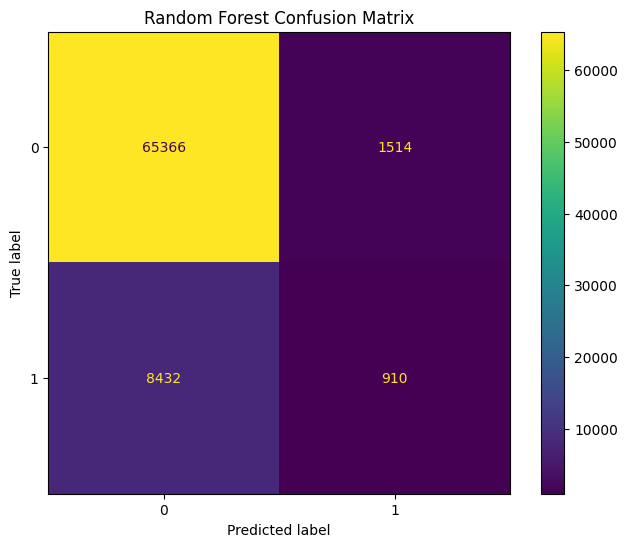

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    ax=ax
)
plt.title("Random Forest Confusion Matrix")
plt.savefig("artifacts/plots/matplotlib/random_forest_confusion_matrix.png")
plt.show()

##### Feature Importance

In [93]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,Vintage,0.255169
7,Annual_Premium,0.233536
1,Age,0.144544
3,Region_Code,0.109281
6,Vehicle_Damage,0.096779
8,Policy_Sales_Channel,0.072113
4,Previously_Insured,0.062524
5,Vehicle_Age,0.014340
0,Gender,0.011088
2,Driving_License,0.000627


##### Feature Importance Plot

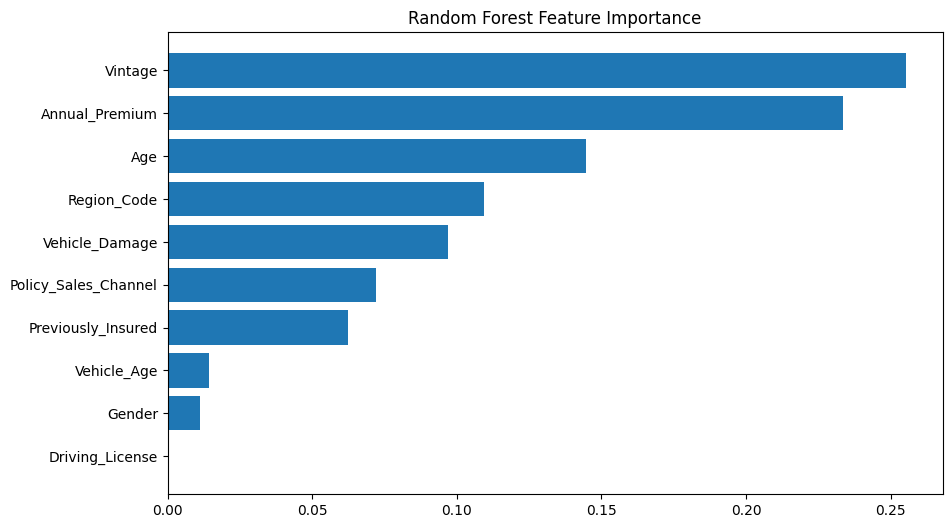

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.savefig("artifacts/plots/matplotlib/random_forest_feature_importance.png")
plt.show()

##### Save Processed Data

In [95]:
import os

os.makedirs("artifacts/preprocessed_data", exist_ok=True)

ml_df.to_csv(
    "artifacts/preprocessed_data/insurance_processed.csv",
    index=False
)

print("✅ Processed dataset saved successfully.")

✅ Processed dataset saved successfully.


### Model Saving

In [96]:
# Save the StandardScaler
joblib.dump(scaler, "artifacts/scalers/scaler.joblib")
print("✅ Scaler saved successfully.")

# Save the LabelEncoders dictionary
joblib.dump(encoders, "artifacts/encoders/encoders.joblib")
print("✅ Encoders saved successfully.")

# Save the trained models
joblib.dump(lr, "artifacts/models/logistic_regression_model.joblib")
print("✅ Logistic Regression model saved.")

joblib.dump(best_rf, "artifacts/models/random_forest_model.joblib")
print("✅ Random Forest model saved.")

joblib.dump(xgb, "artifacts/models/xgboost_model.joblib")
print("✅ XGBoost model saved.")

# Save evaluation results
results_df.to_csv("artifacts/metrics/evaluation_results.csv", index=False)
print("✅ Evaluation results saved.")

✅ Scaler saved successfully.
✅ Encoders saved successfully.
✅ Logistic Regression model saved.
✅ Random Forest model saved.
✅ XGBoost model saved.
✅ Evaluation results saved.


### Zipping The Artifacts Folder

In [97]:
import os
import zipfile

def zip_folder(folder_path, output_path):
    """Zips the contents of a folder."""
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                # Add file to zip, preserving directory structure within the zip
                zipf.write(file_path, os.path.relpath(file_path, folder_path))
    print(f"✅ Folder '{folder_path}' successfully zipped to '{output_path}'.")

# Specify the folder to zip and the output zip file name
folder_to_zip = "artifacts"
output_zip_file = "artifacts.zip"

zip_folder(folder_to_zip, output_zip_file)

✅ Folder 'artifacts' successfully zipped to 'artifacts.zip'.


# Conclusion

This project demonstrates an end-to-end NoSQL analytics workflow using MongoDB concepts and machine learning.

## Project Summary

- Imported and explored the Health Insurance Cross Sell dataset.
- Designed nested MongoDB-style documents using MongoMock.
- Performed CRUD operations on document collections.
- Applied MongoDB aggregation pipelines including:
  - `$match`
  - `$group`
  - `$project`
  - `$sort`
  - `$lookup`
  - `$unwind`
- Converted MongoDB documents into a machine learning-ready DataFrame.
- Preprocessed categorical and numerical features.
- Trained and evaluated multiple machine learning models:
  - Logistic Regression
  - Random Forest
  - XGBoost

## Model Performance

The dataset is highly imbalanced, with a relatively small proportion of positive responses. As a result, baseline models achieved high overall accuracy but comparatively lower recall and F1-score for the minority class. This behavior is expected when using default model parameters without dedicated imbalance-handling techniques.

Future improvements may include:

- Class balancing techniques
- Hyperparameter tuning
- Threshold optimization
- Cross-validation
- SHAP explainability
- Model deployment with Streamlit and a production MongoDB instance

This notebook focuses on demonstrating an end-to-end NoSQL analytics pipeline and establishing a solid foundation for a production-ready machine learning system.